In [1]:
import sys
sys.path.append('../')

import pickle
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as m_colors
import pandas as pd
import statsmodels.api as sm
from tqdm.auto import tqdm
import seaborn as sns
import scipy.stats as stats
import random 

from src.colorconv import ConvexCluster
from src.util import (non_dominated_front,
                      compression,
                      informativeness,
                      degree_of_convexity_cielab,
                      plot_color_grid,
                      plot_n_neighbours,
                      letter_subplots,
                      f1_macro,
                      normalize_labels)

from adjustText import adjust_text


sns.set(context='paper', 
        style='ticks', 
        font_scale=1.1,
        font='serif',
        )

## 0. Defining functions, loading data and plotting misclellaneous figures

Function for artificial data generation:

In [2]:
def generate_grid(n, n_low, n_high, d, X, Y, cielab_list, cielab_dict, cielab_dict_r, prior_m_matrix, p):
    '''
    Function to generate a set of artificial color systems with different
    degrees of convexity.
    '''
    c_values = np.random.uniform(0.001, 0.1, n)
    s_values = np.random.uniform(0.8, 1, n)

    mdl_values = []
    conv_values = []
    cost_values = []
    categ = []
    param_dict = {}
    lgs = []

    for i, sc in tqdm(enumerate(zip(s_values, c_values)), total=n, desc='Generating Grid'):
        N = np.round(np.random.uniform(n_low, n_high), 0).astype(int)
        a = ConvexCluster(X = np.zeros((X, Y)),
                        d = d,
                        N = N,
                        s = sc[0], 
                        c = sc[1],
                        coords=cielab_list,
                        reverse_labels=cielab_dict_r,
                        p=p)
        l = a.run()
        l = np.vstack((l[-1, :], l[:-1, :]))
        l = np.hstack((l[:, -1][:, np.newaxis], l[:, :-1]))
        lgs.append(l)
        param_dict[i] = (sc[0], sc[1], N)
        mdl_values.append(compression(l))
        conv_values.append(a.degree_of_convexity())
        cost_values.append(informativeness(l, 
                                           prior_m_matrix, 
                                           cielab_dict))
        categ.append(N)
    
    return mdl_values, conv_values, cost_values, categ, param_dict, lgs

Unpicking the data:

In [3]:
# unpockle IB_color_naming.pkl from data
with open('../data/IB_color_naming.pkl', 'rb') as f:
    IB_color_naming = pickle.load(f)

# unpickle chip dict
with open('../data/chip_dict.pkl', 'rb') as f:
    chip_dict = pickle.load(f)

# unpickle sielab_dict
with open('../data/cielab_dict.pkl', 'rb') as f:
    cielab_dict = pickle.load(f)   

# unpickle rgb_dict
with open('../data/rgb_dict.pkl', 'rb') as f:
    rgb_dict = pickle.load(f)

# unpickle languages
with open('../data/lg_color.pkl', 'rb') as f:
    lg_color = pickle.load(f)

# unpickle lang_info
with open('../data/lang_info.pkl', 'rb') as f:
    lang_info = pickle.load(f)

In [4]:
# replace -1 with np.nan in lg_color matrices
for lg in lg_color:
    lg_color[lg] = np.where(lg_color[lg] == -1, np.nan, lg_color[lg])

In [5]:
p_m = IB_color_naming['pM']

In [6]:
# get keys from lang_info as a string with ","
print(", ".join(list(lang_info.values())))

Abidji, Agarabi, Casiguran Agta, Aguacateco, Amarakaeri, Ampeeli, Amuzgo, Angaatiha, Apinaye, Arabela, Bahinemo, Bauzi, Berik, Bete, Bhili, Buglere, Cakchiquel, Ucayali Campa, Camsa, Candoshi, Cavinena, Cayapa, Chacobo, Chavacano, Chayahuita, Chinanteco, Chiquitano, Chumburu, Cofan, Colorado, Eastern Cree, Culina, Didinga, Djuka, Dyimini, Ejagam, Ese Ejja, Carib, Guahibo, Guambiano, Guarijio, Ngäbere, Gunu, Halbi, Huasteco, Huave, Iduna, Ifugao, Sepik Iwam, Jicaque, Kalam, Kamano-Kafe, Karaja, Kemtuik, Kokoni, Konkomba, Kriol, Kuku-Yalanji, Long-haired Kuna, Kwerba, Lele, Mampruli, Maring, Martu Wangka, Mawchi, Mayoruna, Mazahua, Mazateco, Menye, Micmac, Mikasuki, Mixteco, Mundu, M{\x9C}ra Pirah{\x8B}, Murle, Murinbata, Nafaanra, Nahuatl, Ocaina, Papago, Patep, Paya, Podopa, Saramaccan, Seri, Shipibo, Siriono, Slave, Sursurunga, Tabla, Tacana, Central Tarahumara, W. Tarahumara, Tboli, Teribe, Ticuna, Tifal, Tlapaneco, Tucano, Vagla, Vasavi, Waorani, Walpiri, Wobe, Yacouba, Yakan, Yamin

Loading the IB prior data:

In [7]:
prior_m = IB_color_naming['pM']

# match index of prior_m to chip_dict coordinates 
# and build a new dict (coordinate: probability)
prior_m_ = []
for i, p in enumerate(prior_m):
    prior_m_.append((chip_dict[i+1], p))

# remove entries with first coordinate == 1
# prior_m_ = [x for x in prior_m_ if x[0][1] != 0]
prior_m_ = [x for x in prior_m_]

# use coordinate from prior_m_ to build a matrix with probabilities
prior_m_matrix = np.zeros((10, 41))
for c, p in prior_m_:
    # prior_m_matrix[c[0]-1, c[1]-1] = p
    prior_m_matrix[c[0]-1, c[1]-1] = p

prior_m_matrix = np.vstack((prior_m_matrix[-1, :], prior_m_matrix[:-1, :]))
# move the last column first
prior_m_matrix = np.hstack((prior_m_matrix[:, -1][:, np.newaxis], prior_m_matrix[:, :-1]))

Exponential demonstration:

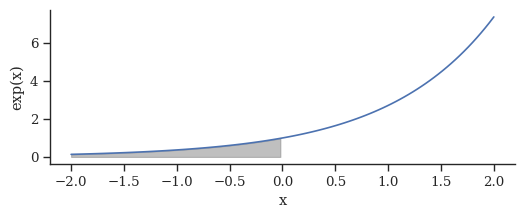

In [8]:
# plot exp of x from -5 to 5
plt.figure(figsize=(6, 2))
x = np.linspace(-2, 2, 100)
y = np.exp(x)
plt.plot(x, y)
plt.xlabel('x')
plt.ylabel('exp(x)')
# color with grey from -2 to 0
plt.fill_between(x, y, where=x < 0, color='grey', alpha=0.5)
sns.despine()
plt.show()

IB prior demonstration:

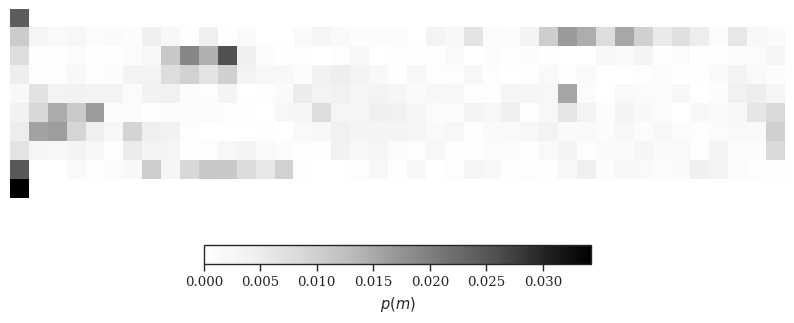

In [33]:
plt.figure(figsize=(10, 4))
plt.imshow(prior_m_matrix, cmap='Greys', interpolation='none')
# remove axes
plt.axis('off')
# Add colorbar at the bottom
cbar = plt.colorbar(orientation='horizontal', shrink=0.5)
cbar.set_label('$p(m)$')
# rasterize
plt.gca().set_rasterized(True)
plt.savefig('../figures/Figure_1s_r.pdf', dpi=300, bbox_inches='tight')
plt.show()

Munsell color space:

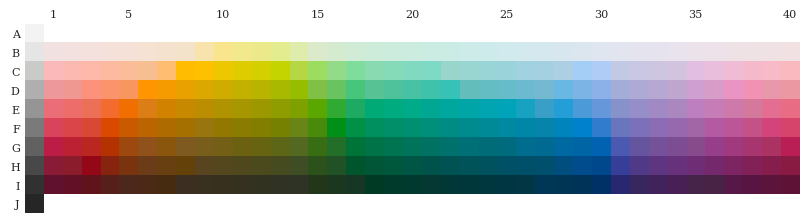

In [10]:
# Extract coordinates and colors from the dictionary
coordinates = list(rgb_dict.keys())
colors = [rgb_dict[coord] for coord in coordinates]

# Convert RGB values to valid color format understood by Matplotlib
colors = [(r, g, b) for r, g, b in colors]

grid_size = (max(coord[0] for coord in coordinates) + 1, 
             max(coord[1] for coord in coordinates) + 1)
image = np.zeros((grid_size[0], grid_size[1], 3))

# Assign colors to pixels
for coord, color in zip(coordinates, colors):
    image[coord[0], coord[1]] = color

# fill empty pixels with white
image[image.sum(axis=2) == 0] = (1, 1, 1)


plt.figure(figsize=(10, 4))
# Plot the image
plt.imshow(image, interpolation='none')
plt.xticks(ticks=[1] + list(range(5, image.shape[1], 5)), 
           labels=[1] + list(range(5, image.shape[1], 5)), fontsize=8)
# yticks should be letters from a to 10th letter
plt.yticks(ticks=np.arange(image.shape[0]), 
           labels=[chr(i) for i in range(65, 65+image.shape[0])], 
           fontsize=8)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['bottom'].set_visible(False)
plt.gca().spines['left'].set_visible(False)
plt.gca().xaxis.tick_top()
plt.gca().tick_params(axis='both', which='both', length=0)
# rasterise the image
plt.gca().set_rasterized(True)
# save to pdf
plt.savefig('../figures/Figure_1a.pdf', 
            bbox_inches='tight', 
            pad_inches=0)

Munsell chips mapped to CIELAB:

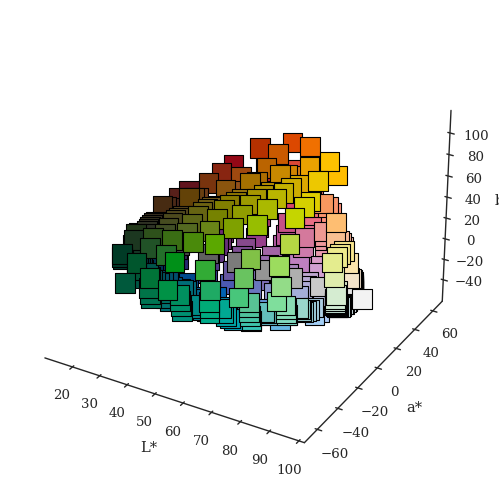

In [11]:
CIELAB_c = dict()

for coord in cielab_dict:
    CIELAB_c[cielab_dict[coord]] = image[coord[0]+1, coord[1]+1]


# plot CIELAB space as 3d scatter plot
fig = plt.figure(figsize=(6, 6))
ax = fig.add_subplot(111, projection='3d')
ax.xaxis.pane.fill = False
ax.yaxis.pane.fill = False
ax.zaxis.pane.fill = False


# Extract coordinates and colors from the dictionary
coordinates = list(CIELAB_c.keys())
colors = list(CIELAB_c.values())

# Convert RGB values to valid color format understood by Matplotlib
colors = [(r, g, b) for r, g, b in colors]

# Plot the points
ax.scatter(*zip(*coordinates), c=colors, 
           s=200, marker='s',
           depthshade=False,
           edgecolors='black',
           )

# add axis labels
ax.set_xlabel('L*')
ax.set_ylabel('a*')
ax.set_zlabel('b*')

ax.xaxis.pane.set_edgecolor('none')
ax.yaxis.pane.set_edgecolor('none')
ax.zaxis.pane.set_edgecolor('none')

# remove grid
ax.grid(False)

# save to pdf
plt.savefig('../figures/Figure_1b.pdf', 
            # bbox_inches='tight', 
            pad_inches=0)

plt.show()

## 1. Preprocessing and data generation

Preprocessing the data:

In [12]:
# only choose coordinates in the range (0, 0), (8, 40)
cielab_dict_ = {k: v for k, v in cielab_dict.items() if k[0] in range(-1, 9) and k[1] in range(-1, 41)}

# reverse keys and values in cielab_dict_
cielab_dict_r = {v: k for k, v in cielab_dict_.items()}

# convert cielab_dict_ to a list of tuples ordered from (0, 0) to (8, 40)
cielab_list = [cielab_dict_[k] for k in sorted(cielab_dict_.keys())]

In [13]:
a = ConvexCluster(X = np.zeros((10, 41)), 
                    d = 2, 
                    N = 10, 
                    s = 1, 
                    c = 0.001,
                    coords = cielab_list,
                    reverse_labels = cielab_dict_r,
                    p = p_m)
labels = a.run()
labels = np.vstack((labels[-1, :], labels[:-1, :]))
labels = np.hstack((labels[:, -1][:, np.newaxis], labels[:, :-1]))

In [14]:
labels.shape

(10, 41)

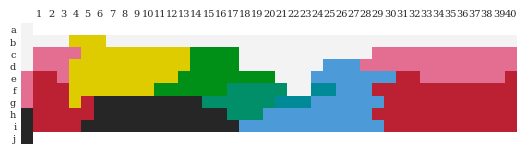

In [15]:
img = plot_color_grid(labels, rgb_dict, prior_m_matrix)
plt.imshow(img, interpolation='none')
plt.xticks(ticks=np.arange(1, img.shape[1]), labels=np.arange(1, img.shape[1]), fontsize=7)
# yticks should be letters from a to 10th letter
plt.yticks(ticks=np.arange(img.shape[0]), 
           labels=[chr(i) for i in range(97, 97+img.shape[0])], 
           fontsize=7)
plt.gca().xaxis.tick_top()
# remove all spines
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['bottom'].set_visible(False)
plt.gca().spines['left'].set_visible(False)
# remove tick marks
plt.gca().tick_params(axis='both', which='both', length=0)
plt.show()

Plotting the hypothetical partitions with the corresponding c and s parameters:

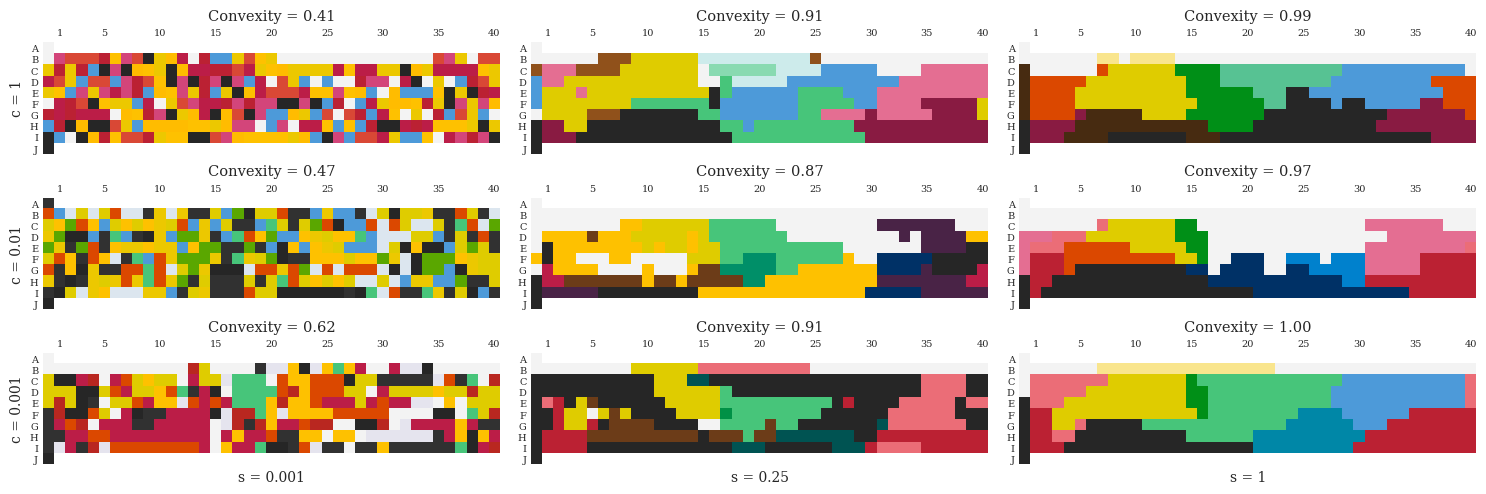

In [16]:
# plot 4 x 4 possible color clusters with parameter smooth in [0.05, 0.25, 1] and conn in [0.0005, 0.01, 1]
fig, ax = plt.subplots(3, 3, figsize=(15, 5))

smooth_values = [0.001, 0.25, 1]
conn_values = [0.001, 0.01, 1]
conn_values = list(reversed(conn_values))

for i, smooth in enumerate(smooth_values):
    for j, conn in enumerate(conn_values):
        a = ConvexCluster(X = np.zeros((10, 41)), 
                          d = 10, 
                          N = 10, 
                          s = smooth, 
                          c = conn,
                          coords = cielab_list,
                          reverse_labels = cielab_dict_r,
                          p = p_m)
        labels = a.run()
        labels = np.vstack((labels[-1, :], labels[:-1, :]))
        labels = np.hstack((labels[:, -1][:, np.newaxis], labels[:, :-1]))
        img = plot_color_grid(labels, rgb_dict, prior_m_matrix)
        ax[i, j].imshow(img, interpolation='none')
        
        # add tick labels
        ax[i, j].set_xticks([1] + list(range(5, img.shape[1], 5)))
        ax[i, j].set_xticklabels([1] + list(range(5, img.shape[1], 5)), fontsize=7)
        ax[i, j].xaxis.tick_bottom()
        ax[i, j].set_yticks(np.arange(img.shape[0]))
        ax[i, j].set_yticklabels([chr(i + 65) for i in range(img.shape[0])], fontsize=7)
        ax[i, j].xaxis.tick_top()
        # rasterize the image
        ax[i, j].set_rasterized(True)

        # remove tick marks
        ax[i, j].tick_params(axis='both', which='both', length=0)
        
        ax[i, j].set_title(f'Convexity = {a.degree_of_convexity():.2f}')
        for spine in ax[i, j].spines.values():
            spine.set_visible(False)
        
# Label the leftmost column with conn values
for i, conn in enumerate(conn_values):
    ax[i, 0].set_ylabel('c = ' + str(conn), fontsize=10)

# Label the bottom row with smooth values
for j, smooth in enumerate(smooth_values):
    ax[2, j].set_xlabel('s = ' + str(smooth), fontsize=10)

plt.tight_layout()
plt.savefig('../figures/Figure_3.pdf', bbox_inches='tight', pad_inches=0)
plt.show()

In [17]:
a = ConvexCluster(X = np.zeros((10, 41)), 
                         d = 10, 
                         N = 20, 
                         s = 1, 
                         c = 0.001,
                         coords = cielab_list,
                         reverse_labels = cielab_dict_r,
                         p = p_m)
labels = a.run()
labels = np.vstack((labels[-1, :], labels[:-1, :]))
labels = np.hstack((labels[:, -1][:, np.newaxis], labels[:, :-1]))
img = plot_color_grid(labels, rgb_dict, prior_m_matrix)

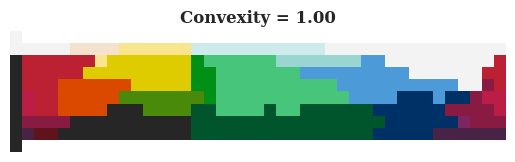

In [18]:
plt.figure()
plt.imshow(img, interpolation='none')
plt.xticks([])
plt.yticks([])
# remove border
for spine in plt.gca().spines.values():
    spine.set_visible(False)
plt.title(f'Convexity = {a.degree_of_convexity():.2f}', fontsize=12, weight='bold')
plt.show()

In [19]:
round(informativeness(labels, prior_m_matrix, cielab_dict), 2)

-10.05

Generate artificial grids (commented out, as the data is already generated):

In [20]:
results = generate_grid(n = 10000, 
                        d = 10, 
                        X = 10,
                        Y = 41,
                        n_low = 3,
                        n_high = 16,
                        cielab_list = cielab_list,
                        cielab_dict = cielab_dict,
                        cielab_dict_r = cielab_dict_r,
                        prior_m_matrix = prior_m_matrix,
                        p = p_m)

Generating Grid:   0%|          | 0/10000 [00:00<?, ?it/s]

In [21]:
# # uncomment to perform the same analysis but with the
# # uniform prior over the 330 chips

# p_m_uniform = np.ones((330, 1)) / 330

# results_u = generate_grid(n = 3000, 
#                         d = 10, 
#                         X = 10,
#                         Y = 41,
#                         n_low = 3,
#                         n_high = 16,
#                         cielab_list = cielab_list,
#                         cielab_dict = cielab_dict,
#                         cielab_dict_r = cielab_dict_r,
#                         prior_m_matrix = prior_m_matrix,
#                         p = p_m_uniform)

Load the data:

In [22]:
# # import results from pickle
# with open('../data/convex_cluster_results_110225.pkl', 'rb') as f:
#     results = pickle.load(f)

# # write results to pickle
# with open('../data/convex_cluster_results_120225.pkl', 'wb') as f:
#     pickle.dump(results, f)

mdl_values, conv_values, cost_values, categ, param_dict, lgs = results

# iterate over cost_values, if a value is inf, then remove it from the list and from the other lists
for i, val in enumerate(cost_values):
    if np.isinf(val):
        mdl_values.pop(i)
        conv_values.pop(i)
        categ.pop(i)
        cost_values.pop(i)

Estimate the Pareto front:

In [23]:
pareto_front_indices = non_dominated_front(mdl_values, cost_values)
pareto_front_points = [(mdl_values[i], cost_values[i]) for i in pareto_front_indices]

# find duplicates in either x or y and remove them
pareto_front_points = list(set(pareto_front_points))

x_pareto, y_pareto = zip(*pareto_front_points)

In [24]:
# create a smooth line over x_pareto and y_pareto using lowess
lowess = sm.nonparametric.lowess
smoothed = lowess(y_pareto, x_pareto, frac=0.2)

Read the generated data and extract the partitions and their metrics:

Calculate the distances to the Pareto front for the artificial data:

In [25]:
# for each point in (mdl_values, cost_values), calculate the distance to the points in the pareto front
distances = []

x_pareto = np.array(x_pareto)
y_pareto = np.array(y_pareto)

for i, j in zip(mdl_values, cost_values):
    distances.append(abs(np.min(np.sqrt((i - x_pareto)**2 + (j - y_pareto)**2))))

Compute the metrics for the WCS data:

In [26]:
# enumerate over grids in lg_color and calculate informativeness
informativeness_values = []
simplicity_values = []
categ_values = []
lg_ids = list(lg_color.keys())

for grid in lg_color:
    informativeness_values.append(informativeness(lg_color[grid], prior_m_matrix, cielab_dict))
    simplicity_values.append(compression(lg_color[grid]))
    categ_values.append(len(np.unique(lg_color[grid])))

# measure the degree of convexity for each grid in lg_color
convexity_values = degree_of_convexity_cielab(np.array([lg_color[lg] for lg in lg_ids]), cielab_dict, cielab_list)
# compute the number of categories for each grid in lg_color
categories_values = [len(np.unique(lg_color[grid])) - 1 for grid in lg_color]
# compute the distance to the pareto front for each grid in lg_color
distances_values = [abs(np.min(np.sqrt((simplicity_values[i] - x_pareto)**2 + 
                                   (informativeness_values[i] - y_pareto)**2))) for i in range(len(simplicity_values))]

In [27]:
n_cat = []
for key, grid in lg_color.items():
    unique_vals = np.unique(grid)
    # exclude NaN values
    unique_vals = unique_vals[~np.isnan(unique_vals)]
    n_cat.append(len(unique_vals))

In [28]:
min(n_cat), max(n_cat)

(3, 16)

## 2. Analysis

### 2.1. Pareto front

Plot the artificial data and the Pareto front:

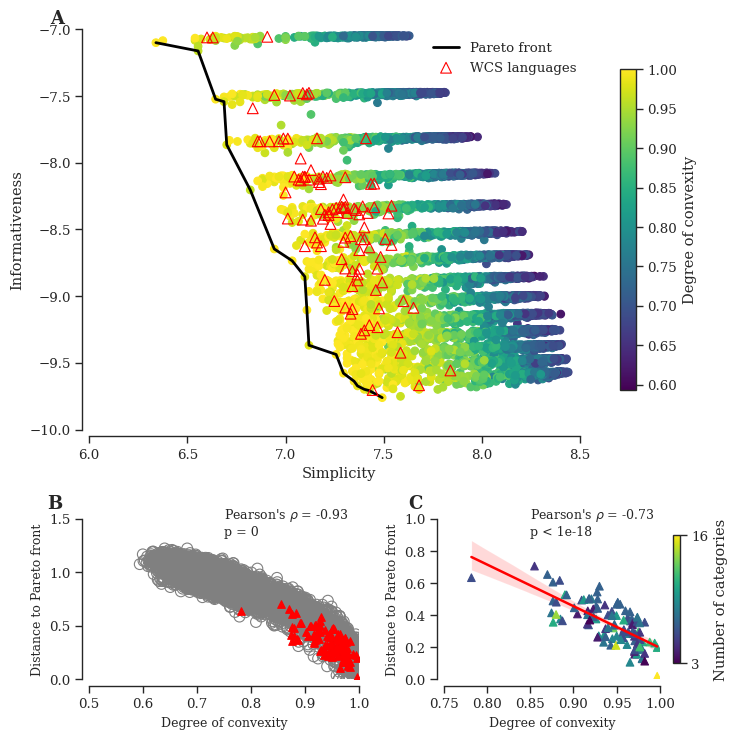

In [ ]:
# Create a helper function to format p-value automatically
def format_p(p):
    if p == 0:
        return "p = 0"
    n = int(np.floor(np.log10(p)))
    return f"p < 1e{n}"


# Create a GridSpec for the layout: top plot spans both columns
fig = plt.figure(figsize=(7.5, 7.5))
gs = fig.add_gridspec(2, 2, height_ratios=[2.5, 1])  # 2 rows, 2 columns with different heights

# SUBPLOT A
ax1 = fig.add_subplot(gs[0, :])  # Span the entire top row
# Plot with convexity
scatter1 = ax1.scatter(mdl_values, cost_values, 
                       c=conv_values, cmap='viridis', 
                       alpha=1,
                       s=30,  
                       facecolors='none',
                       norm=m_colors.Normalize(vmin=min(conv_values), vmax=1))
ax1.plot(smoothed[:, 0], smoothed[:, 1], 
         color='black', alpha=1,  
         linewidth=2, label='Pareto front')
ax1.scatter(simplicity_values, informativeness_values, 
            color='red', marker='^', s=60, label='WCS languages', zorder=10,
            facecolors='none',)
scatter1.set_rasterized(True)
ax1.set_xlabel('Simplicity')
ax1.set_ylabel('Informativeness')
cbar1 = fig.colorbar(scatter1, ax=ax1, shrink=0.8, label='Degree of convexity')
ax1.legend(loc='upper right', frameon=False)
ax1.set_xlim(6, None)
ax1.set_ylim(-10, -7)
sns.despine(ax=ax1, 
            offset=5, 
            trim=True)
ax1.text(-0.05, 1.05, 'A', transform=ax1.transAxes, fontsize=13, 
         fontweight='bold', va='top', ha='right')

# SUBPLOT B
ax2 = fig.add_subplot(gs[1, 0])
scatter2 = ax2.scatter(conv_values, distances, color='grey', alpha=1, s=60, facecolors='none')
scatter2.set_rasterized(True)
ax2.scatter(convexity_values, distances_values, color='red', marker='^', s=30)
r1, p1 = stats.pearsonr(conv_values, distances)
ax2.text(0.5, 0.9, f"Pearson's $\\rho$ = {r1:.2f}\n" + format_p(p1), 
         fontsize=9, transform=ax2.transAxes)
ax2.set_xlabel('Degree of convexity', fontsize=9)
ax2.set_ylabel('Distance to Pareto front', fontsize=9)
ax2.set_ylim(0, 1.5)
ax2.set_xlim(0.5, 1)
sns.despine(ax=ax2, 
            offset=5, 
            trim=True)
ax2.text(-0.1, 1.15, 'B', transform=ax2.transAxes, fontsize=13, 
         fontweight='bold', va='top', ha='right')

# SUBPLOT C
ax3 = fig.add_subplot(gs[1, 1])
sns.regplot(x=convexity_values, y=distances_values, 
            scatter=False, color='red', ax=ax3)
scatter = ax3.scatter(convexity_values, distances_values, 
                      c=categories_values, alpha=1, s=30, cmap='viridis',
                      marker='^',
                      norm=plt.Normalize(vmin=3, vmax=16))
cbar = fig.colorbar(scatter, ax=ax3, label='Number of categories', shrink=0.8, ticks=[3, 16])
r2, p2 = stats.pearsonr(convexity_values, distances_values)
ax3.text(0.4, 0.9, f"Pearson's $\\rho$ = {r2:.2f}\n" + format_p(p2), 
         fontsize=9, transform=ax3.transAxes)
ax3.set_xlabel('Degree of convexity', fontsize=9)
ax3.set_ylabel('Distance to Pareto front', fontsize=9)
ax3.set_ylim(0, 1)
ax3.set_xlim(0.75, 1)
sns.despine(ax=ax3, 
            offset=5, 
            trim=True
            )
ax3.text(-0.1, 1.15, 'C', transform=ax3.transAxes, fontsize=13, 
         fontweight='bold', va='top', ha='right')

plt.tight_layout()
plt.savefig('../figures/Figure_4.pdf', dpi=300, bbox_inches='tight')
plt.show()

In [30]:
# save the most optimal artificial languages in a file (save the coordinates in the simplicity, informativeness space)
optimal_languages = [np.array([simp, info]) for simp, info in pareto_front_points]

# save to pickle
with open('../data/optimal_artificial_languages.pkl', 'wb') as f:
    pickle.dump(optimal_languages, f)

### 2.2. Correlation between convexity, informativeness, and simplicity

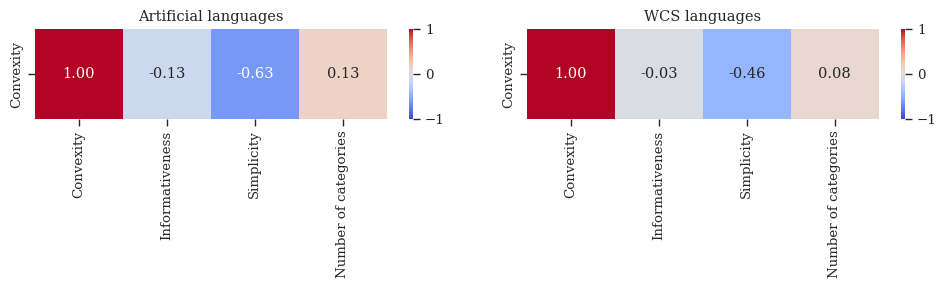

In [31]:
# plot correlation matrix with convexity as rows only
fig, ax = plt.subplots(1, 2, figsize=(10, 3))

# Artificial languages
df_artificial = pd.DataFrame({
    'Convexity': conv_values,
    'Informativeness': cost_values,
    'Simplicity': mdl_values,
    'Number of categories': categ
})
sns.heatmap(df_artificial.corr().loc[['Convexity']], annot=True, 
            fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1, ax=ax[0])
ax[0].set_title('Artificial languages')

# WCS languages
df_wcs = pd.DataFrame({
    'Convexity': convexity_values,
    'Informativeness': informativeness_values,
    'Simplicity': simplicity_values,
    'Number of categories': categ_values
})
sns.heatmap(df_wcs.corr().loc[['Convexity']], annot=True, 
            fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1, ax=ax[1])
ax[1].set_title('WCS languages')

plt.tight_layout()
plt.show()

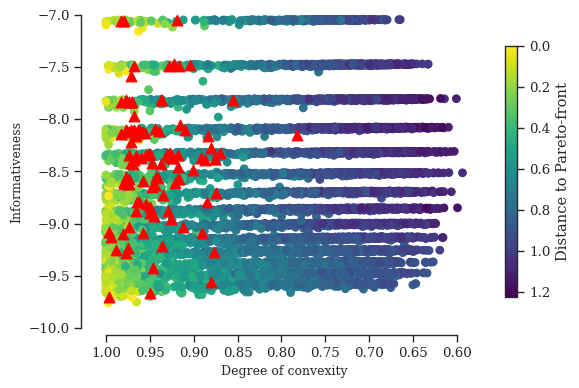

In [32]:
fig, ax = plt.subplots(figsize=(6, 4))

# plot convexity vs informativeness (artificial languages)
scatter = ax.scatter(conv_values, cost_values,
                     c=distances, cmap='viridis_r',
                     alpha=1, s=30,
                     facecolors='none',
                     norm=m_colors.Normalize(vmin=min(distances), vmax=max(distances)))
# colorbar
cbar = fig.colorbar(scatter, ax=ax, shrink=0.8, label='Distance to Pareto-front')
cbar.ax.invert_yaxis()
# ax.legend(loc='upper right', frameon=False)
# cbar.set_norm(m_colors.Normalize(vmin=min(distances), vmax=max(distances)))


# labels and style
ax.set_xlabel('Degree of convexity', fontsize=9)
ax.set_ylabel('Informativeness', fontsize=9)
ax.set_ylim(-10, -7)
sns.despine(ax=ax, offset=5, trim=True)

# flip the x axis
ax.invert_xaxis()

# now add WCS languages
ax.scatter(convexity_values, informativeness_values, 
           color='red', marker='^', s=60, label='WCS languages', zorder=10,)


plt.tight_layout()
plt.show()